正在計算 Center of Gravity 控制曲面...
正在計算 Mean of Maxima 控制曲面...
正在計算 Modified MOM 控制曲面...
正在計算 Center Average 控制曲面...


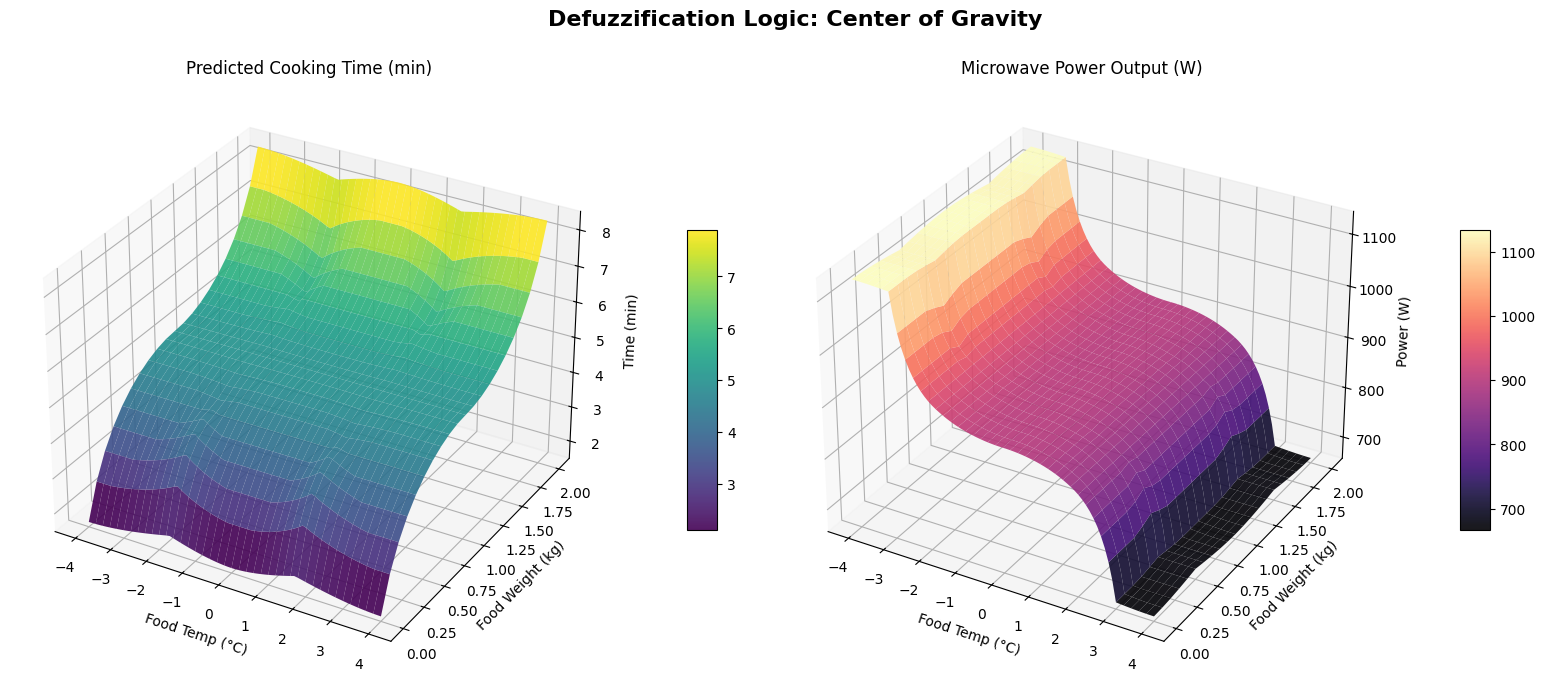

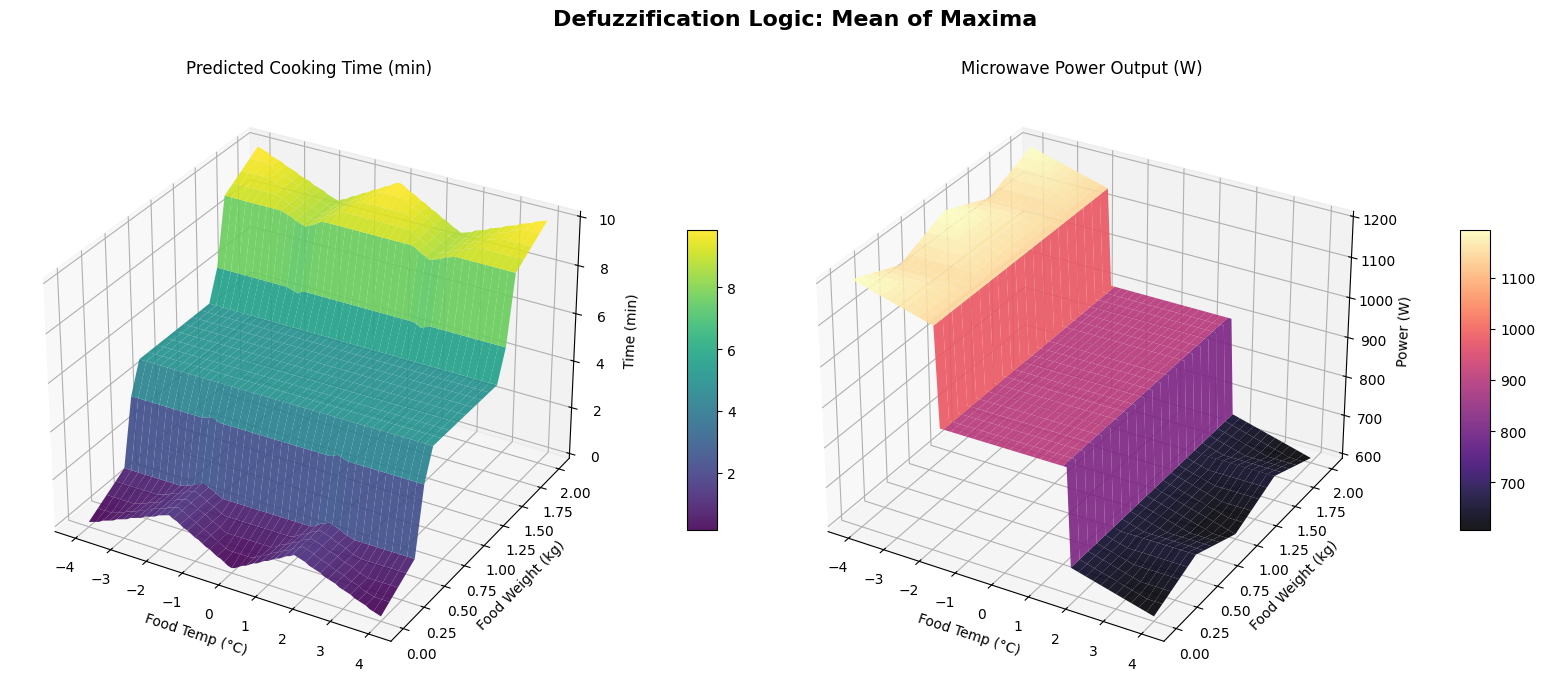

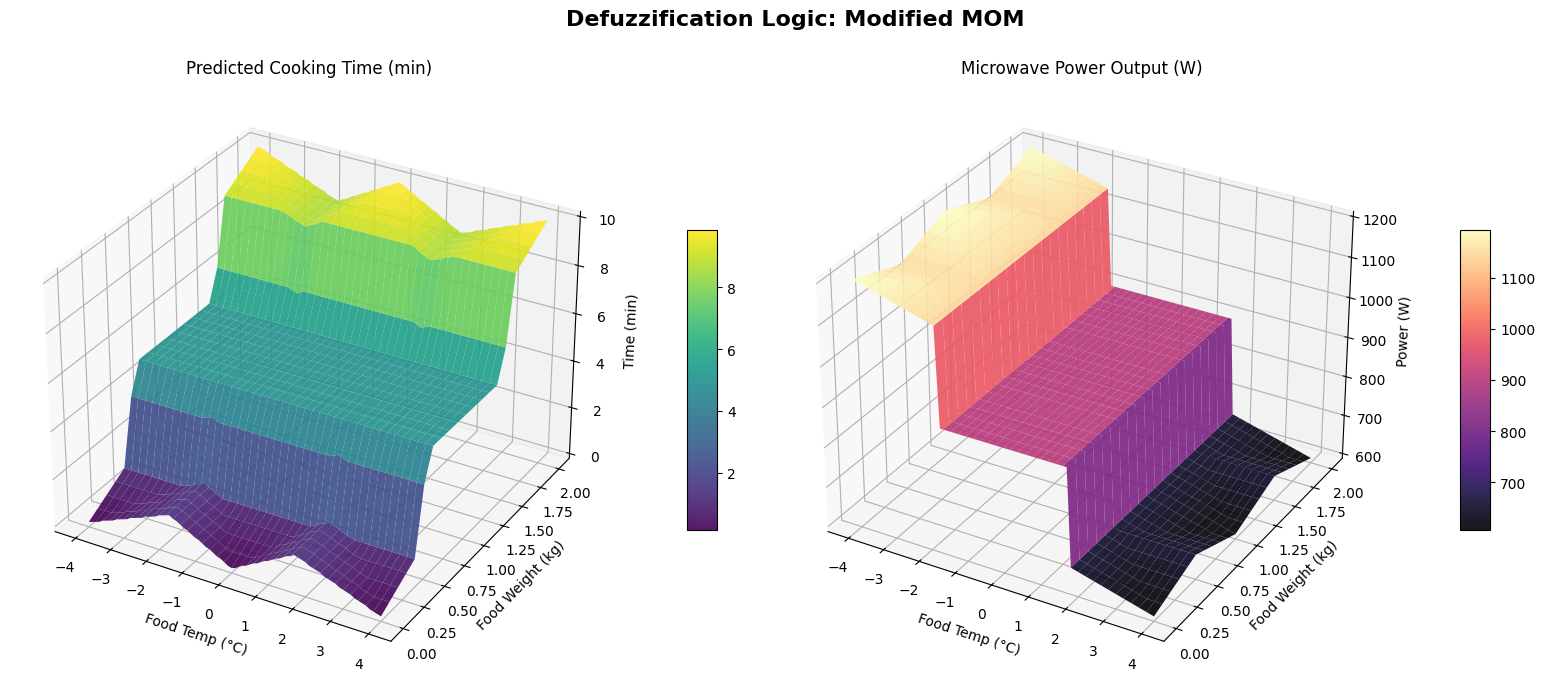

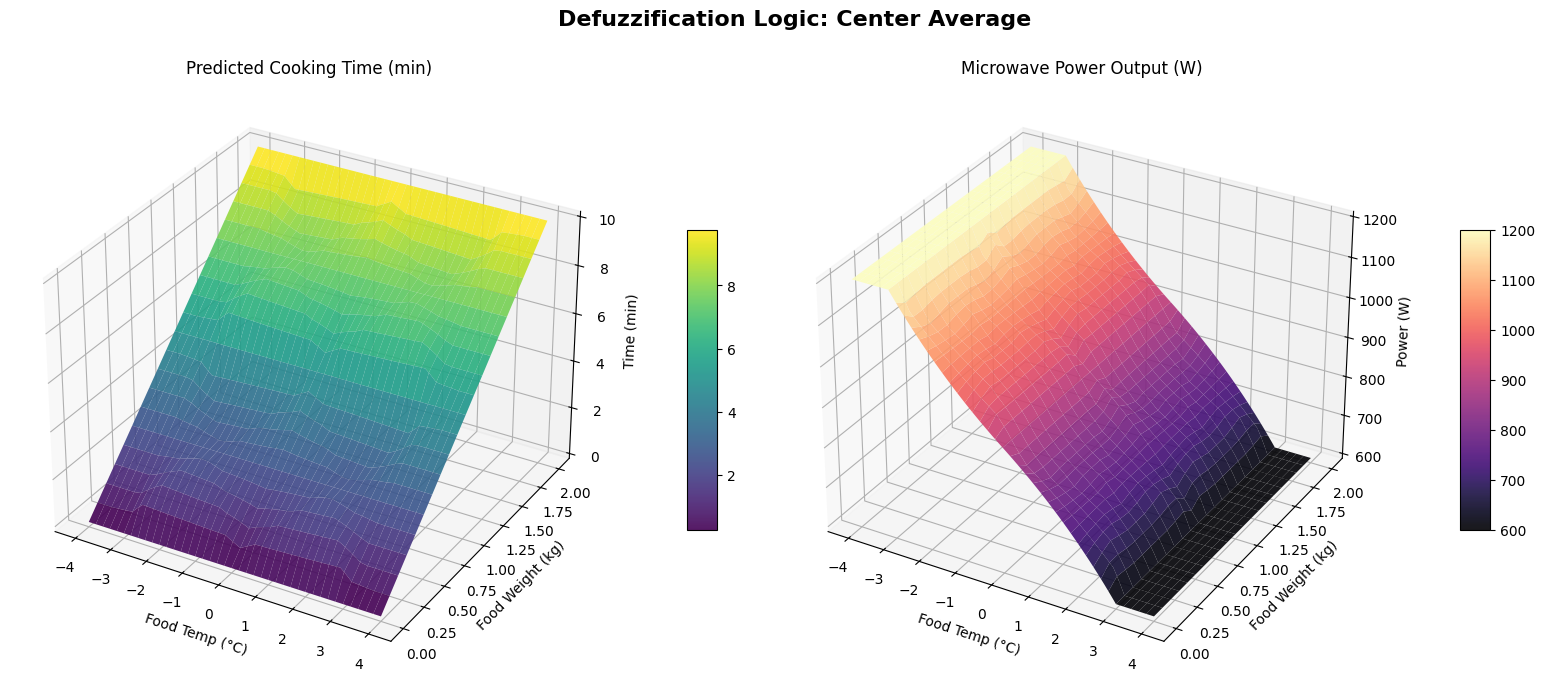


所有分析圖表已成功生成至資料夾：microwave_fuzzy_results


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =====================================================
# 1. 建立輸出資料夾
# =====================================================
output_folder = "microwave_fuzzy_results"
os.makedirs(output_folder, exist_ok=True)

# =====================================================
# 2. 定義論域 (Universe of Discourse)
# =====================================================
temp_domain = np.arange(-4, 4.01, 0.1)      # 食物溫度 x (°C)
weight_domain = np.arange(0, 2.01, 0.1)     # 食物重量 y (kg)
time_domain = np.arange(0, 10.01, 0.1)      # 加熱時間 z (min)
power_domain = np.arange(600, 1200.1, 1)    # 微波功率 w (Watt)

# =====================================================
# 3. 隸屬函數定義 (Membership Functions)
# =====================================================
def trimf(val, a, b, c):
    val = np.asarray(val)
    mu = np.zeros_like(val, dtype=float)
    left = (a < val) & (val <= b)
    right = (b < val) & (val < c)
    if b != a: mu[left] = (val[left] - a) / (b - a)
    if c != b: mu[right] = (c - val[right]) / (c - b)
    mu[val == b] = 1.0
    return np.clip(mu, 0, 1)

def left_shoulder(val, a, b):
    val = np.asarray(val)
    mu = np.zeros_like(val, dtype=float)
    mu[val <= a] = 1.0
    mid = (a < val) & (val < b)
    mu[mid] = (b - val[mid]) / (b - a)
    return np.clip(mu, 0, 1)

def right_shoulder(val, a, b):
    val = np.asarray(val)
    mu = np.zeros_like(val, dtype=float)
    mu[val <= a] = 0.0
    mid = (a < val) & (val < b)
    mu[mid] = (val[mid] - a) / (b - a)
    mu[val >= b] = 1.0
    return np.clip(mu, 0, 1)

# --- 輸入集合 ---
def fuzzy_temp_low(x):  return left_shoulder(x, -4, 0)
def fuzzy_temp_med(x):  return trimf(x, -3, 0, 3)
def fuzzy_temp_high(x): return right_shoulder(x, 0, 4)

def fuzzy_weight_light(y): return left_shoulder(y, 0, 1)
def fuzzy_weight_med(y):   return trimf(y, 0, 1, 2)
def fuzzy_weight_heavy(y): return right_shoulder(y, 1, 2)

# --- 輸出集合 ---
def fuzzy_time_short(z): return left_shoulder(z, 0, 5)
def fuzzy_time_med(z):   return trimf(z, 0, 5, 10)
def fuzzy_time_long(z):  return right_shoulder(z, 5, 10)

def fuzzy_power_low(w):  return left_shoulder(w, 600, 800)
def fuzzy_power_med(w):  return trimf(w, 600, 900, 1200)
def fuzzy_power_high(w): return right_shoulder(w, 1000, 1200)

# ======================================================
# 4. 去模糊化核心工具
# ======================================================
def get_cog(domain, mu):
    denom = np.sum(mu)
    return np.sum(domain * mu) / denom if denom != 0 else np.nan

def get_mom(domain, mu):
    max_mu = np.max(mu)
    if max_mu == 0: return np.nan
    return np.mean(domain[np.isclose(mu, max_mu)])

def get_modified_mom(domain, mu):
    max_mu = np.max(mu)
    if max_mu == 0: return np.nan
    max_pts = domain[np.isclose(mu, max_mu)]
    return (np.min(max_pts) + np.max(max_pts)) / 2

# ======================================================
# 5. 微波爐模糊推論邏輯 (Mamdani Inference)
# ======================================================
def microwave_control_inference(curr_temp, curr_weight, method='cog'):
    # Fuzzification
    m_t = [fuzzy_temp_low(curr_temp), fuzzy_temp_med(curr_temp), fuzzy_temp_high(curr_temp)]
    m_w = [fuzzy_weight_light(curr_weight), fuzzy_weight_med(curr_weight), fuzzy_weight_heavy(curr_weight)]

    # 規則強度計算 (R1-R9)
    alpha = np.array([
        min(m_t[0], m_w[2]), min(m_t[0], m_w[1]), min(m_t[0], m_w[0]), # R1-R3
        min(m_t[1], m_w[2]), min(m_t[1], m_w[1]), min(m_t[1], m_w[0]), # R4-R6
        min(m_t[2], m_w[2]), min(m_t[2], m_w[1]), min(m_t[2], m_w[0])  # R7-R9
    ])

    # 輸出標籤映射
    time_labels = ['long', 'medium', 'short'] * 3
    pwr_labels = ['high']*3 + ['medium']*3 + ['low']*3

    # 特殊處理：Center Average (CA)
    if method == 'center_average':
        t_centers = {'short': 0.0, 'medium': 5.0, 'long': 10.0}
        p_centers = {'low': 600.0, 'medium': 900.0, 'high': 1200.0}
        t_c = np.array([t_centers[l] for l in time_labels])
        p_c = np.array([p_centers[l] for l in pwr_labels])
        if np.sum(alpha) == 0: return 5.0, 900.0
        return np.sum(alpha * t_c) / np.sum(alpha), np.sum(alpha * p_c) / np.sum(alpha)

    # Aggregation (Max-Min)
    time_agg = np.zeros_like(time_domain)
    pwr_agg = np.zeros_like(power_domain)

    time_sets = [fuzzy_time_long, fuzzy_time_med, fuzzy_time_short] * 3
    pwr_sets = [fuzzy_power_high]*3 + [fuzzy_power_med]*3 + [fuzzy_power_low]*3

    for a, t_func, p_func in zip(alpha, time_sets, pwr_sets):
        if a > 0:
            time_agg = np.maximum(time_agg, np.minimum(a, t_func(time_domain)))
            pwr_agg = np.maximum(pwr_agg, np.minimum(a, p_func(power_domain)))

    # 去模糊化計算
    if method == 'cog':
        return get_cog(time_domain, time_agg), get_cog(power_domain, pwr_agg)
    elif method == 'mom':
        return get_mom(time_domain, time_agg), get_mom(power_domain, pwr_agg)
    elif method == 'modified_mom':
        return get_modified_mom(time_domain, time_agg), get_modified_mom(power_domain, pwr_agg)
    return 5.0, 900.0

# =====================================================
# 6. 生成控制曲面數據
# =====================================================
methods = ['cog', 'mom', 'modified_mom', 'center_average']
method_names = {'cog': 'Center of Gravity', 'mom': 'Mean of Maxima',
                'modified_mom': 'Modified MOM', 'center_average': 'Center Average'}

simulation_results = {}
for m in methods:
    print(f'正在計算 {method_names[m]} 控制曲面...')
    X, Y = np.meshgrid(temp_domain, weight_domain)
    Z_time = np.zeros_like(X); W_pwr = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z_time[i,j], W_pwr[i,j] = microwave_control_inference(X[i,j], Y[i,j], method=m)
    simulation_results[m] = (X, Y, Z_time, W_pwr)

# =====================================================
# 7. 繪圖展示
# =====================================================
for m_key in methods:
    grid_X, grid_Y, time_surf, pwr_surf = simulation_results[m_key]

    canvas = plt.figure(figsize=(16, 7))
    canvas.suptitle(f'Defuzzification Logic: {method_names[m_key]}', fontsize=16, fontweight='bold')

    # --- 左圖：加熱時間 (Time) ---
    ax_time = canvas.add_subplot(1, 2, 1, projection='3d')
    surf_t = ax_time.plot_surface(grid_X, grid_Y, time_surf, cmap='viridis', edgecolor='none', alpha=0.9)
    ax_time.set_title('Predicted Cooking Time (min)')
    ax_time.set_xlabel('Food Temp (°C)'); ax_time.set_ylabel('Food Weight (kg)'); ax_time.set_zlabel('Time (min)')
    ax_time.view_init(elev=30, azim=-60)
    canvas.colorbar(surf_t, ax=ax_time, shrink=0.5, aspect=10, pad=0.1)

    # --- 右圖：微波功率 (Power) ---
    ax_pwr = canvas.add_subplot(1, 2, 2, projection='3d')
    surf_p = ax_pwr.plot_surface(grid_X, grid_Y, pwr_surf, cmap='magma', edgecolor='none', alpha=0.9)
    ax_pwr.set_title('Microwave Power Output (W)')
    ax_pwr.set_xlabel('Food Temp (°C)'); ax_pwr.set_ylabel('Food Weight (kg)'); ax_pwr.set_zlabel('Power (W)')
    ax_pwr.view_init(elev=30, azim=-60)
    canvas.colorbar(surf_p, ax=ax_pwr, shrink=0.5, aspect=10, pad=0.1)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(os.path.join(output_folder, f"paired_{m_key}.png"), dpi=300)
    plt.show()

print(f"\n所有分析圖表已成功生成至資料夾：{output_folder}")